# 03 — Visualization & EDA

Exploratory analysis of the cleaned Sobol dataset (2524 rows) before model training: input/output distributions, correlation structure, input-vs-output relationships, and mutual information between the 7 sampled inputs and the 4 ML target outputs.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

## Loading the Cleaned Dataset

In [2]:
df = pd.read_csv(
    "../data/04_processed_dwsim/sobol_training_cleaned.csv"
)

print(df.shape)

(2524, 23)


## Distribution of Input Variables

All 7 are sampled inputs from the Sobol sequence, so we'd expect roughly uniform coverage across their locked ranges — this is a sanity check that the sampling actually behaved as intended.

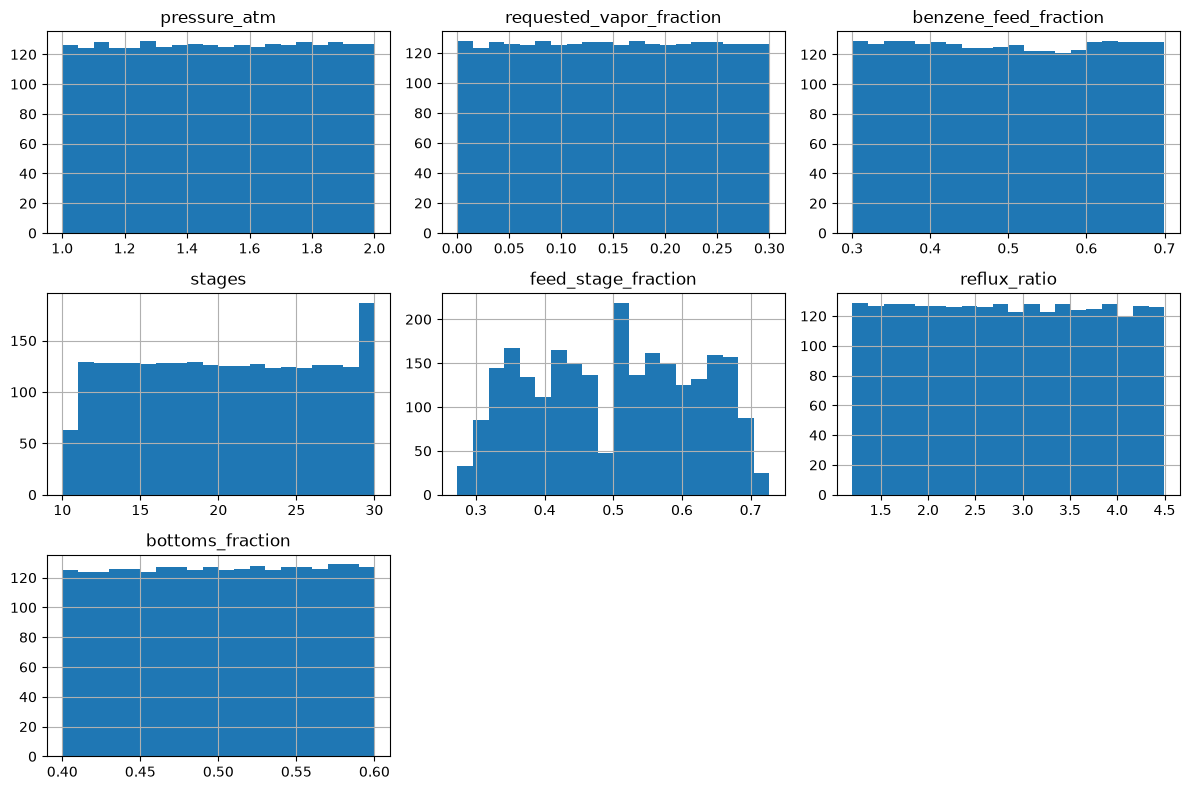

In [3]:
input_columns = [
    "pressure_atm",
    "requested_vapor_fraction",
    "benzene_feed_fraction",
    "stages",
    "feed_stage_fraction",
    "reflux_ratio",
    "bottoms_fraction"
]

df[input_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

## Distribution of Output Variables

`x_D_benzene` piles up near 1 and `x_B_benzene` piles up near 0 — that's physically expected for a distillation column doing its job: the distillate should be benzene-rich and the bottoms benzene-lean across most of the sampled operating space, with the harder separation cases (near-equal reflux/stage combinations) filling out the tail toward the middle.

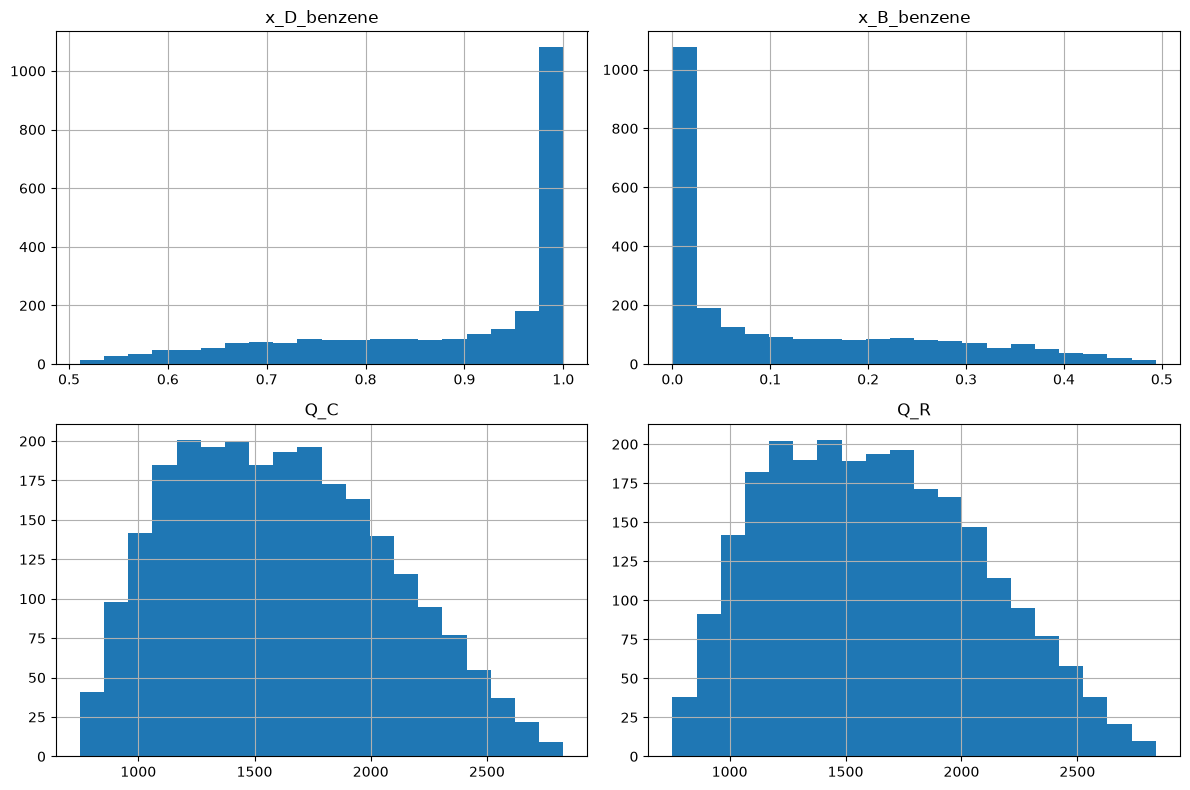

In [4]:
output_columns = [
    "x_D_benzene",
    "x_B_benzene",
    "Q_C",
    "Q_R"
]

df[output_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

## Input-Output Correlation

Linear correlation only — useful as a first pass, but several of the relationships here are known to be nonlinear (e.g. purity vs. reflux ratio saturates near the bounds), so this is complemented by the mutual information analysis further down.

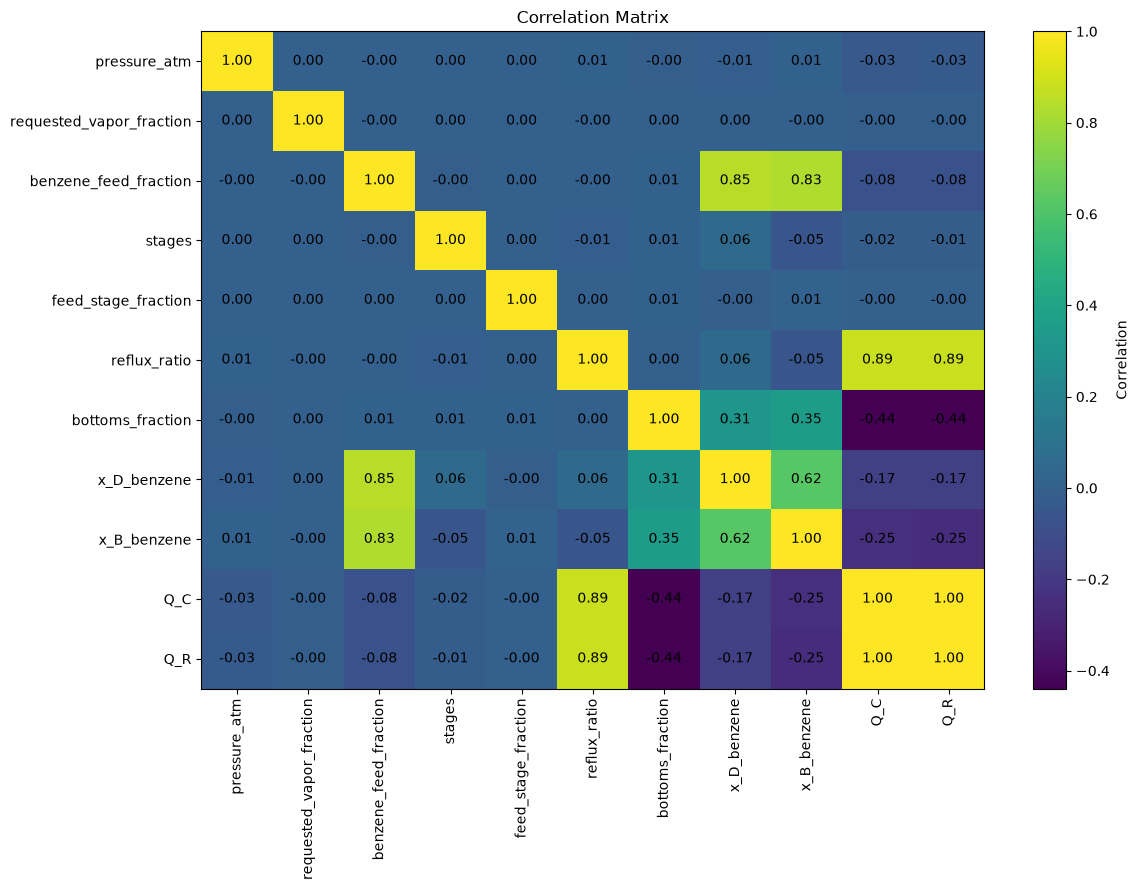

In [5]:
input_columns = [
    "pressure_atm",
    "requested_vapor_fraction",
    "benzene_feed_fraction",
    "stages",
    "feed_stage_fraction",
    "reflux_ratio",
    "bottoms_fraction"
]

output_columns = [
    "x_D_benzene",
    "x_B_benzene",
    "Q_C",
    "Q_R"
]

corr_columns = input_columns + output_columns

corr = df[corr_columns].corr()

plt.figure(figsize=(12, 9))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

`Q_C` and `Q_R` are very strongly correlated with each other, as expected — condenser and reboiler duty are tightly linked by the column's energy balance. `reflux_ratio` shows the strongest correlation with both duties, which makes physical sense: reflux ratio directly drives internal vapor/liquid traffic and therefore heat duty.

## Input vs Distillate Composition

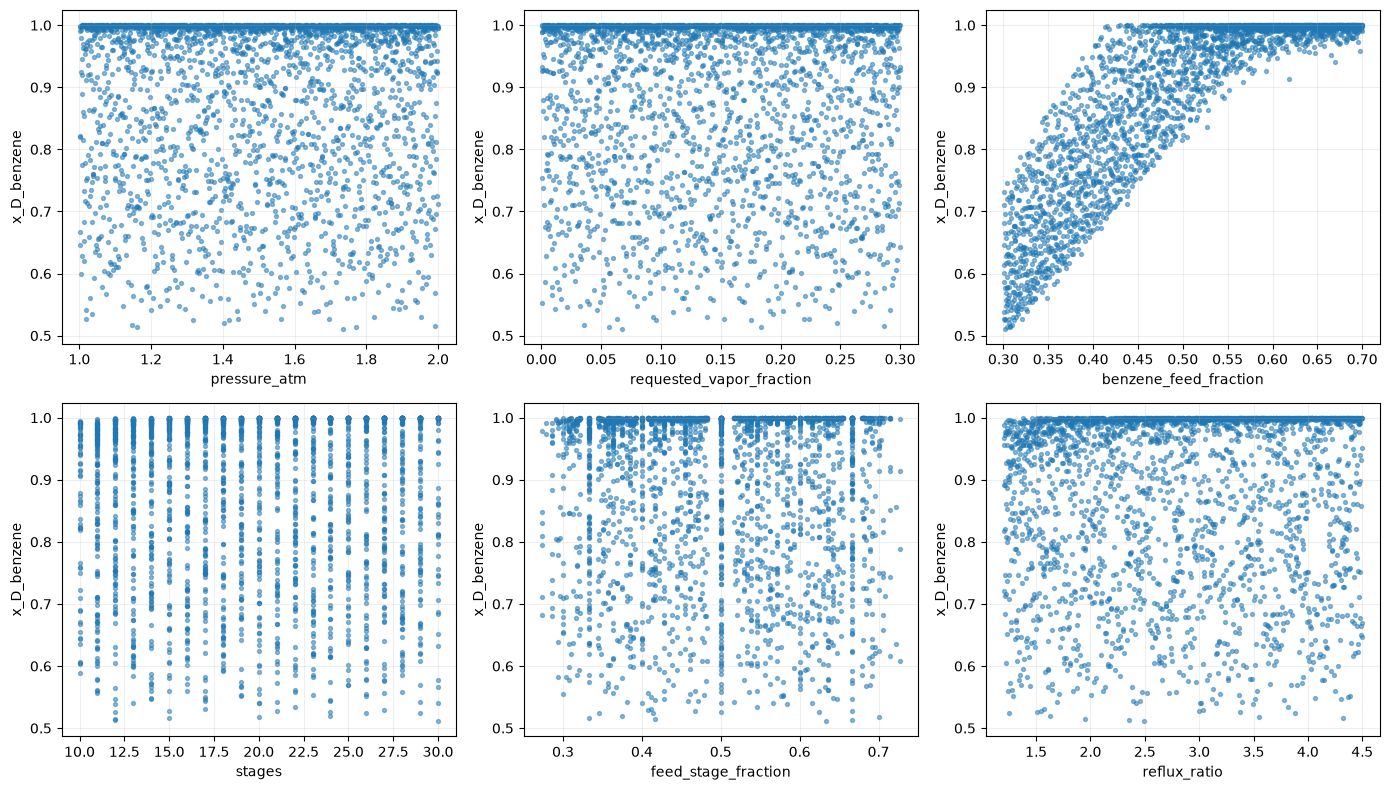

In [6]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

for ax, column in zip(
        axes.ravel(),
        input_columns
):
    ax.scatter(
        df[column],
        df["x_D_benzene"],
        s=8,
        alpha=0.5
    )

    ax.set_xlabel(column)
    ax.set_ylabel("x_D_benzene")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

`benzene_feed_fraction` shows the clearest trend against `x_D_benzene` among the six inputs plotted here — richer benzene feed pushes distillate purity up, though the relationship flattens out once purity is already near 1 (a ceiling effect, not noise).

## Input vs Bottoms Composition

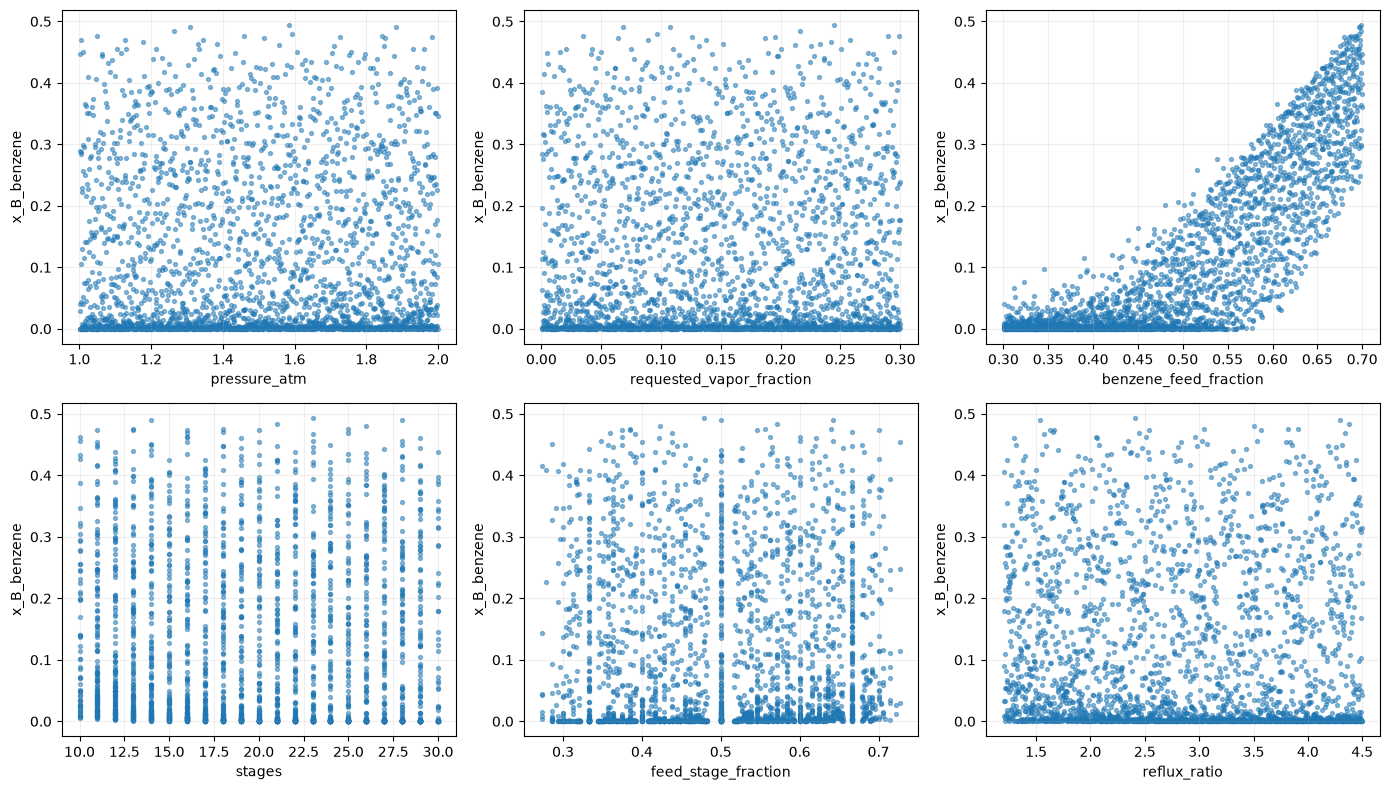

In [7]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

for ax, column in zip(
        axes.ravel(),
        input_columns
):
    ax.scatter(
        df[column],
        df["x_B_benzene"],
        s=8,
        alpha=0.5
    )

    ax.set_xlabel(column)
    ax.set_ylabel("x_B_benzene")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Same pattern in reverse for `x_B_benzene`: as benzene feed fraction rises, bottoms purity (of benzene) also shifts, but the more interesting driver visually is `reflux_ratio` and `bottoms_fraction` — higher reflux does a better job of stripping benzene out of the bottoms.

## Input vs Condenser Duty

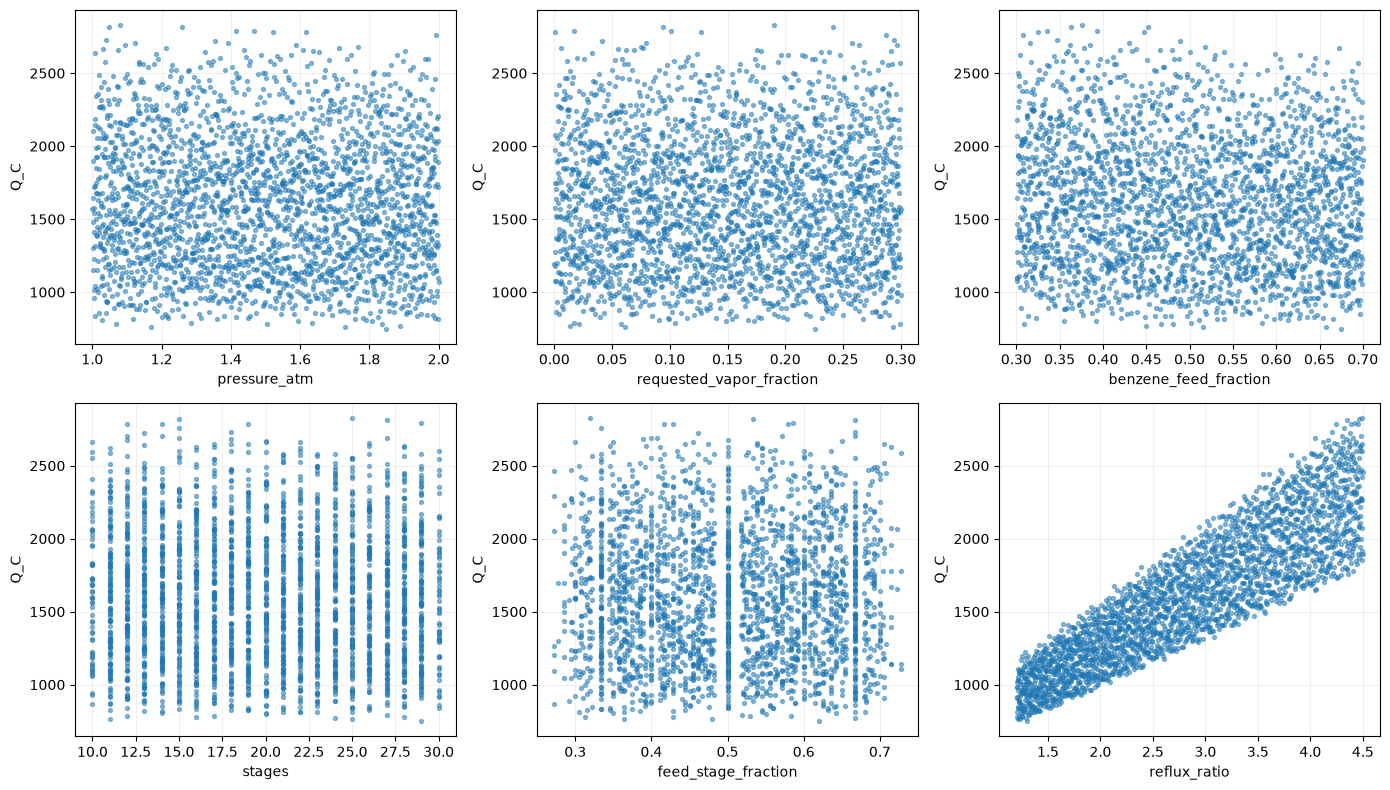

In [8]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

for ax, column in zip(
        axes.ravel(),
        input_columns
):
    ax.scatter(
        df[column],
        df["Q_C"],
        s=8,
        alpha=0.5
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Q_C")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

`reflux_ratio` has an obvious near-linear relationship with `Q_C`, consistent with the correlation matrix above.

## Input vs Reboiler Duty

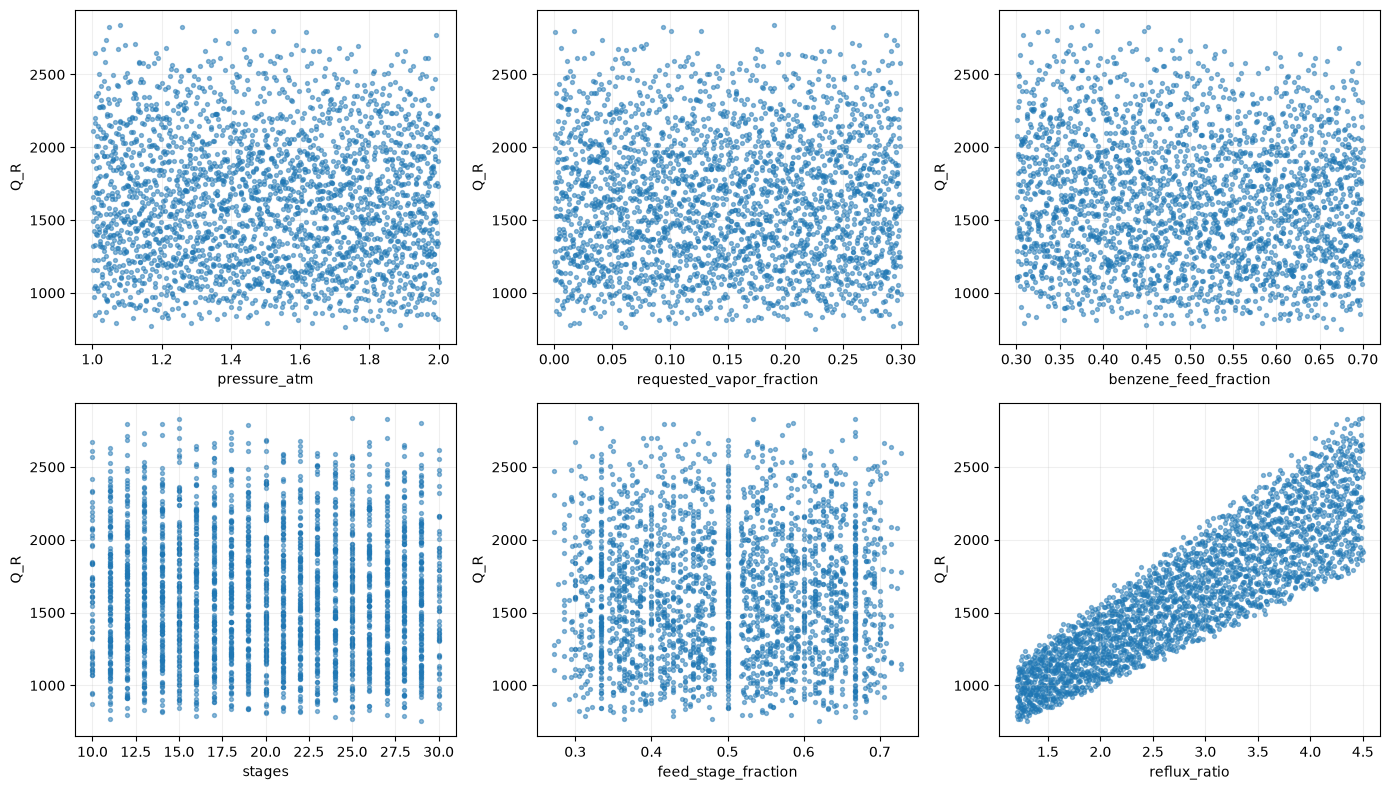

In [9]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

for ax, column in zip(
        axes.ravel(),
        input_columns
):
    ax.scatter(
        df[column],
        df["Q_R"],
        s=8,
        alpha=0.5
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Q_R")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

`Q_R` mirrors `Q_C` closely against every input, again pointing at how tightly linked condenser and reboiler duty are in this system.

## Condenser Duty vs Reboiler Duty

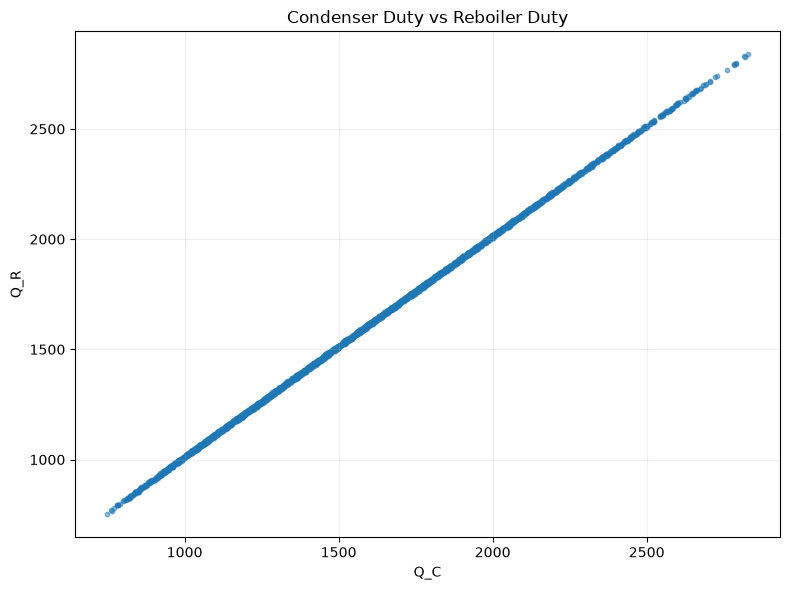

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Q_C"],
    df["Q_R"],
    s=10,
    alpha=0.5
)

plt.xlabel("Q_C")
plt.ylabel("Q_R")
plt.title("Condenser Duty vs Reboiler Duty")
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Feature and Target Selection

## Feature and Target Selection

**Correction:** an earlier version of this cell used an 8-column feature set (including both `feed_stage` and `feed_stage_fraction`, which are redundant — one is derived from the other) and a 5-column target set that included `feed_temperature_C`. Per the project's locked design, feed temperature is a **derived** post-simulation quantity (computed by DWSIM from the sampled pressure, vapor fraction, and composition), not an independently sampled input or a modeling target — so it's excluded from both `X` and `y` here. The correct spec is the 7 sampled inputs already defined above (`input_columns`) against the 4 ML outputs (`output_columns`).

In [11]:
feature_columns = [
    "pressure_atm",
    "requested_vapor_fraction",
    "benzene_feed_fraction",
    "stages",
    "feed_stage",
    "feed_stage_fraction",
    "reflux_ratio",
    "bottoms_fraction"
]

target_columns = [
    "feed_temperature_C",
    "x_D_benzene",
    "x_B_benzene",
    "Q_C",
    "Q_R"
]

X = df[feature_columns]
y = df[target_columns]

print("Features shape:", X.shape)
print("Targets shape:", y.shape)

Features shape: (2524, 8)
Targets shape: (2524, 5)


In [12]:
# Reuse the already-defined 7-input / 4-output spec (see cells above) rather than
# redefining a separate, inconsistent feature/target list here.
X = df[input_columns]
y = df[output_columns]

print("Features shape:", X.shape)
print("Targets shape:", y.shape)

Features shape: (2524, 7)
Targets shape: (2524, 4)


## Mutual Information

## Mutual Information

Rerun with the corrected 4-output target set (`output_columns`), so this now reflects the final 7-input → 4-output modeling setup rather than the earlier 5-output version that still included `feed_temperature_C`.

In [13]:
mi_scores = {}

for target in target_columns:

    mi = mutual_info_regression(
        df[input_columns],
        df[target],
        random_state=42
    )

    mi_scores[target] = mi

mi_df = pd.DataFrame(
    mi_scores,
    index=input_columns
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6f}"
)

display(mi_df)


,feed_temperature_C,x_D_benzene,x_B_benzene,Q_C,Q_R
pressure_atm,0.688585,0.000000,0.000000,0.000000,0.000000
requested_vapor_fraction,0.000000,0.000000,0.000000,0.000000,0.000000
benzene_feed_fraction,0.000000,0.702568,0.638729,0.000000,0.000000
stages,0.027781,0.112476,0.105336,0.000000,0.000000
feed_stage_fraction,0.000000,0.104160,0.129358,0.000000,0.000000
reflux_ratio,0.001165,0.086131,0.045481,0.809490,0.801216
bottoms_fraction,0.014308,0.000000,0.032961,0.121389,0.115202


In [14]:
mi_scores = {}

for target in output_columns:

    mi = mutual_info_regression(
        df[input_columns],
        df[target],
        random_state=42
    )

    mi_scores[target] = mi

mi_df = pd.DataFrame(
    mi_scores,
    index=input_columns
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6f}"
)

display(mi_df)

,x_D_benzene,x_B_benzene,Q_C,Q_R
pressure_atm,0.000000,0.000000,0.000000,0.000000
requested_vapor_fraction,0.000000,0.000000,0.000000,0.000000
benzene_feed_fraction,0.702568,0.638729,0.000000,0.000000
stages,0.112476,0.105336,0.000000,0.000000
feed_stage_fraction,0.104160,0.129358,0.000000,0.000000
reflux_ratio,0.086131,0.045481,0.809490,0.801216
bottoms_fraction,0.000000,0.032961,0.121389,0.115202


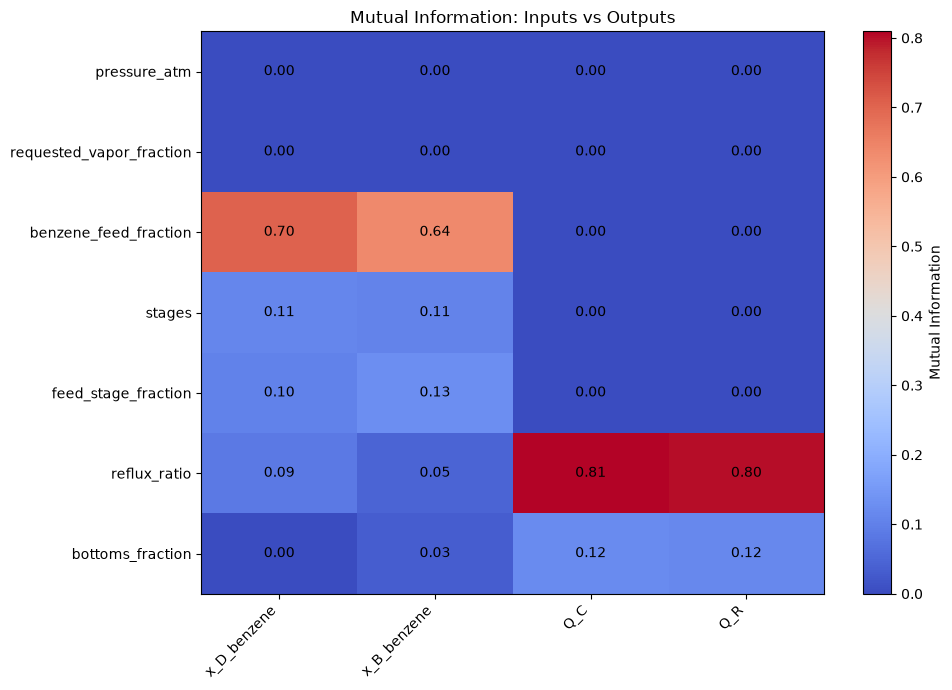

In [15]:
plt.figure(figsize=(10, 7))

plt.imshow(
    mi_df,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Mutual Information")

plt.xticks(
    range(len(mi_df.columns)),
    mi_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(mi_df.index)),
    mi_df.index
)

for i in range(len(mi_df.index)):
    for j in range(len(mi_df.columns)):
        plt.text(
            j,
            i,
            f"{mi_df.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Mutual Information: Inputs vs Outputs")

plt.tight_layout()
plt.show()